<a href="https://colab.research.google.com/github/queleandrade/estatistica_ciencias_dados/blob/main/modulo1_analise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Módulo I – Análise Estatística
Tradução do script R para Python (Google Colab)

> **Instruções:** Faça upload do arquivo `banco1_modulo1.xlsx` clicando no ícone de pasta 📁 no painel esquerdo do Colab e depois em *Upload*. Em seguida, execute as células em ordem.

## 1. Instalação e Importação de Bibliotecas

In [1]:
# Instalar pacotes necessários (apenas no Colab)
!pip install scikit_posthocs --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from scipy import stats
from scipy.stats import (shapiro, chi2_contingency, fisher_exact,
                         pearsonr, spearmanr, levene, bartlett,
                         mannwhitneyu, kruskal, ttest_ind, f_oneway)

import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols

import scikit_posthocs as sp
import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 2. Importação do Banco de Dados

In [4]:
# Leitura do arquivo Excel
# Certifique-se de ter feito upload do arquivo banco1_modulo1.xlsx
banco1_modulo1 = pd.read_excel('banco1_modulo1.xlsx')

# Visualizar as primeiras linhas
display(banco1_modulo1.head())
print('\nDimensões:', banco1_modulo1.shape)
print('\nColunas:', list(banco1_modulo1.columns))

,N,EstadoCivil,GrauInstrucao,N_Filhos,Salario_Min,Anos,Meses,Regiao_Procedencia,GrauInstrucao1
0,2,casado,ens_fundamental,1.0,4.56,32,10,capital,1
1,3,casado,ens_fundamental,2.0,5.25,36,5,capital,1
2,8,solteiro,ens_fundamental,NaN,7.39,43,4,capital,1
3,12,solteiro,ens_fundamental,NaN,8.46,27,11,capital,1
4,1,solteiro,ens_fundamental,NaN,4.00,26,3,interior,1



Dimensões: (30, 9)

Colunas: ['N', 'EstadoCivil', 'GrauInstrucao', 'N_Filhos', 'Salario_Min', 'Anos', 'Meses', 'Regiao_Procedencia', 'GrauInstrucao1']


In [5]:
# Atalhos para as colunas (equivalente ao attach() do R)
GrauInstrucao      = banco1_modulo1['GrauInstrucao']
Salario_Min        = banco1_modulo1['Salario_Min']
Regiao_Procedencia = banco1_modulo1['Regiao_Procedencia']
EstadoCivil        = banco1_modulo1['EstadoCivil']
Anos               = banco1_modulo1['Anos']
Meses              = banco1_modulo1['Meses']
N_Filhos           = banco1_modulo1['N_Filhos']

## 3. Análise Gráfica

### 3.1 Gráfico de Setores (Pizza) – básico

GrauInstrucao
ens_medio          16
ens_fundamental    12
superior            2
Name: count, dtype: int64


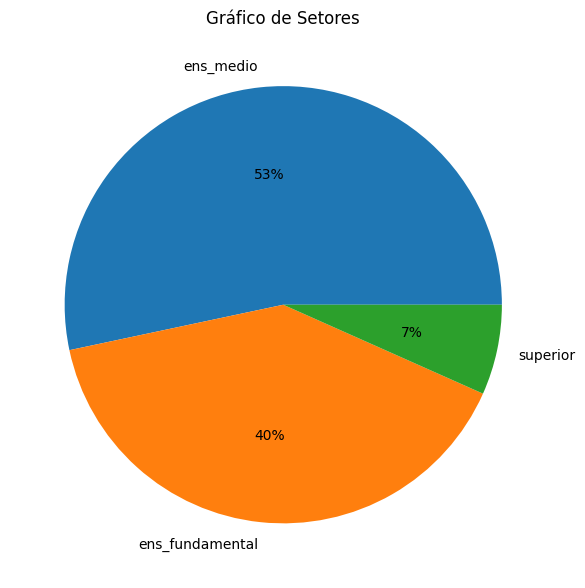

In [6]:
tabInstrucao = GrauInstrucao.value_counts()
print(tabInstrucao)

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(tabInstrucao, labels=tabInstrucao.index, autopct='%1.0f%%')
ax.set_title('Gráfico de Setores')
plt.tight_layout()
plt.show()

### 3.2 Gráfico de Setores com Legenda e Percentuais

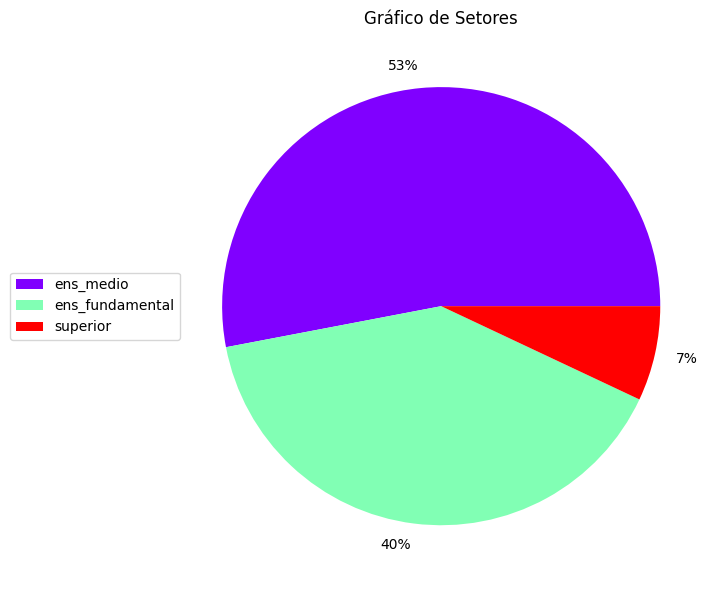

In [7]:
probInst = tabInstrucao / tabInstrucao.sum()
porc = (probInst * 100).round().astype(int)
categorias = porc.index.tolist()
rotulos = [f'{v}%' for v in porc.values]
cores = plt.cm.rainbow(np.linspace(0, 1, len(porc)))

fig, ax = plt.subplots(figsize=(7, 6))
ax.pie(porc, labels=rotulos, colors=cores)
ax.legend(categorias, loc='center left', bbox_to_anchor=(-0.3, 0.5))
ax.set_title('Gráfico de Setores')
plt.tight_layout()
plt.show()

### 3.3 Gráfico em Colunas – básico

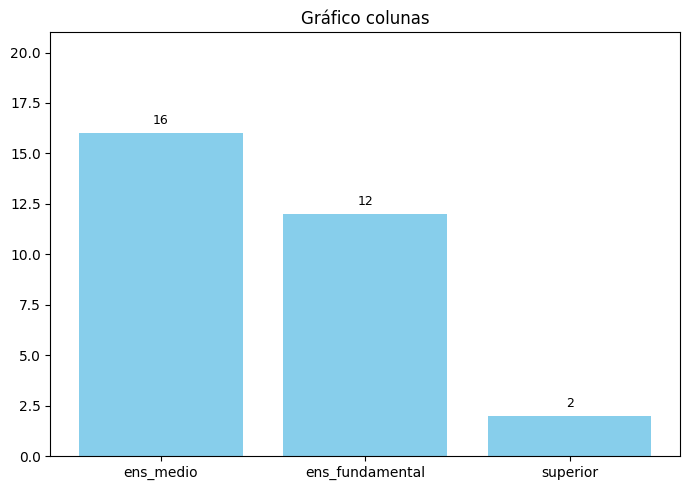

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(tabInstrucao.index, tabInstrucao.values, color='skyblue')
ax.set_ylim(0, tabInstrucao.max() + 5)
ax.set_title('Gráfico colunas')

# Valores acima das barras
for bar, val in zip(bars, tabInstrucao.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 3.4 Gráfico em Colunas com Seaborn (equivalente ao ggplot)

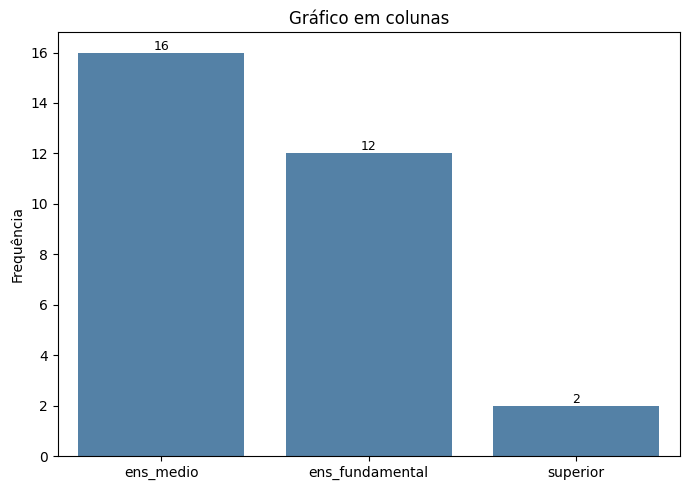

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ordem = GrauInstrucao.value_counts().index
sns.countplot(data=banco1_modulo1, x='GrauInstrucao',
              order=ordem, color='steelblue', ax=ax)

# Adicionar contagens acima das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

ax.set_title('Gráfico em colunas')
ax.set_xlabel('')
ax.set_ylabel('Frequência')
sns.set_style('whitegrid')
plt.tight_layout()
plt.show()

### 3.5 Gráfico em Barras Agrupadas

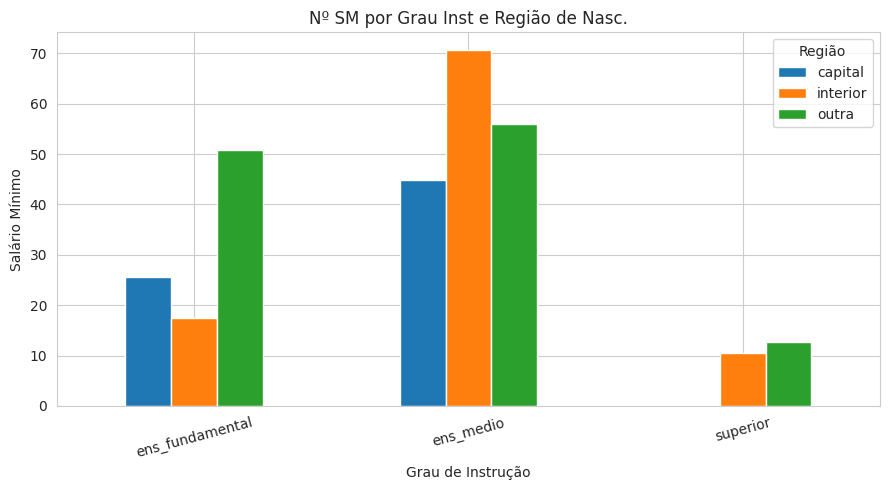

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
pivot = banco1_modulo1.groupby(['GrauInstrucao', 'Regiao_Procedencia'])['Salario_Min'].sum().unstack()
pivot.plot(kind='bar', ax=ax)
ax.set_title('Nº SM por Grau Inst e Região de Nasc.')
ax.set_xlabel('Grau de Instrução')
ax.set_ylabel('Salário Mínimo')
ax.legend(title='Região')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 3.6 Boxplot – Idade (Anos)

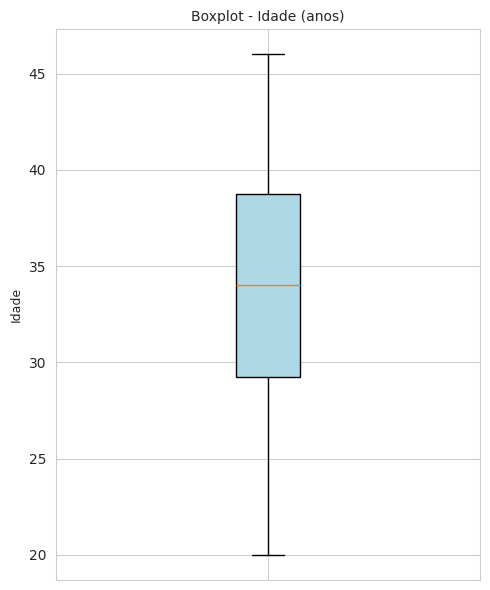

In [11]:
fig, ax = plt.subplots(figsize=(5, 6))
ax.boxplot(Anos.dropna(), patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
ax.set_ylabel('Idade', fontsize=9)
ax.set_title('Boxplot - Idade (anos)', fontsize=10)
ax.set_xticklabels([''])
plt.tight_layout()
plt.show()

### 3.7 Boxplot por Grupo – Salário por Escolaridade

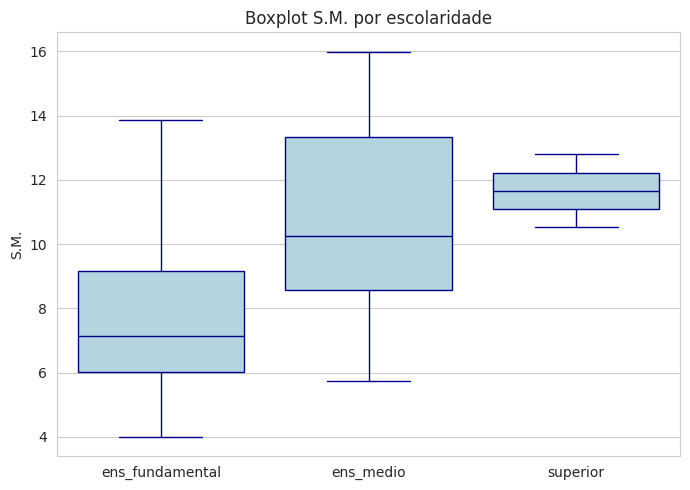

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=banco1_modulo1, x='GrauInstrucao', y='Salario_Min',
            color='lightblue', linecolor='darkblue', ax=ax)
ax.set_title('Boxplot S.M. por escolaridade')
ax.set_xlabel('')
ax.set_ylabel('S.M.')
plt.tight_layout()
plt.show()

### 3.8 Boxplot com Pontos – Idade por Escolaridade

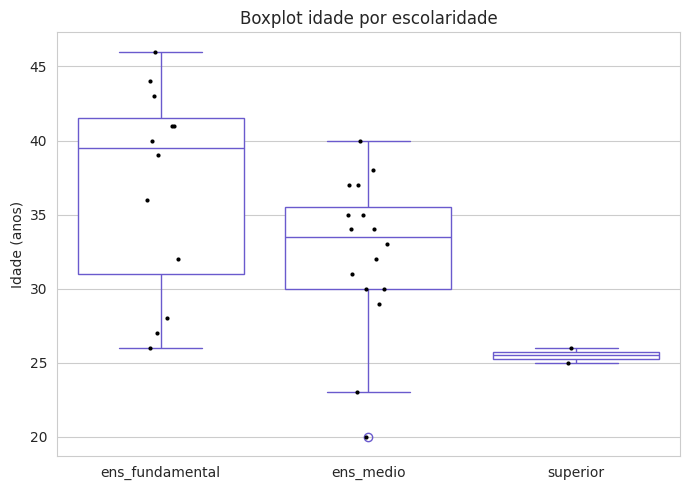

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=banco1_modulo1, x='GrauInstrucao', y='Anos',
            color='white', linecolor='slateblue', ax=ax)
sns.stripplot(data=banco1_modulo1, x='GrauInstrucao', y='Anos',
              color='black', size=3, jitter=True, ax=ax)
ax.set_title('Boxplot idade por escolaridade')
ax.set_xlabel('')
ax.set_ylabel('Idade (anos)')
plt.tight_layout()
plt.show()

### 3.9 Boxplot com Pontos – Meses por Escolaridade

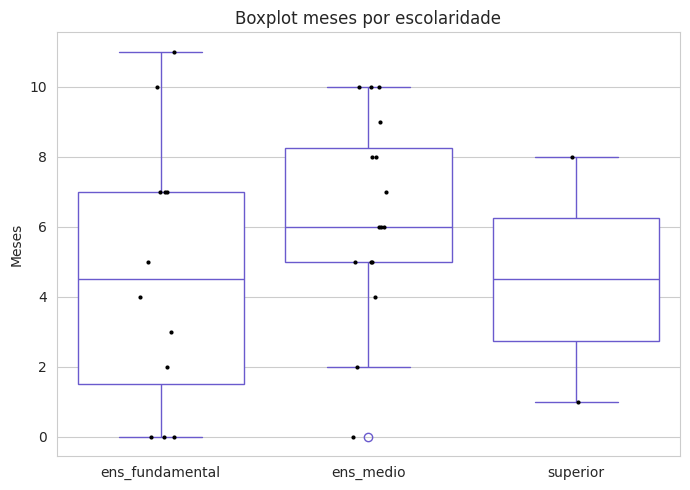

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=banco1_modulo1, x='GrauInstrucao', y='Meses',
            color='white', linecolor='slateblue', ax=ax)
sns.stripplot(data=banco1_modulo1, x='GrauInstrucao', y='Meses',
              color='black', size=3, jitter=True, ax=ax)
ax.set_title('Boxplot meses por escolaridade')
ax.set_xlabel('')
ax.set_ylabel('Meses')
plt.tight_layout()
plt.show()

### 3.10 Histograma – Idade

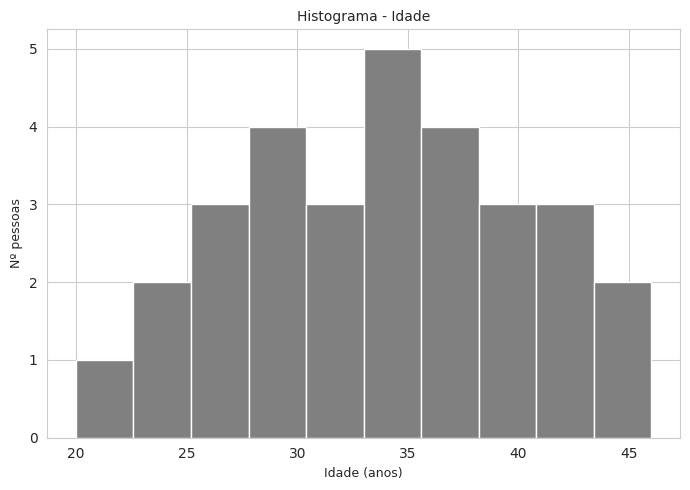

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(Anos.dropna(), color='gray', edgecolor='white')
ax.set_xlabel('Idade (anos)', fontsize=9)
ax.set_ylabel('Nº pessoas', fontsize=9)
ax.set_title('Histograma - Idade', fontsize=10)
plt.tight_layout()
plt.show()

### 3.11 Gráfico de Pontos – Nº de Filhos

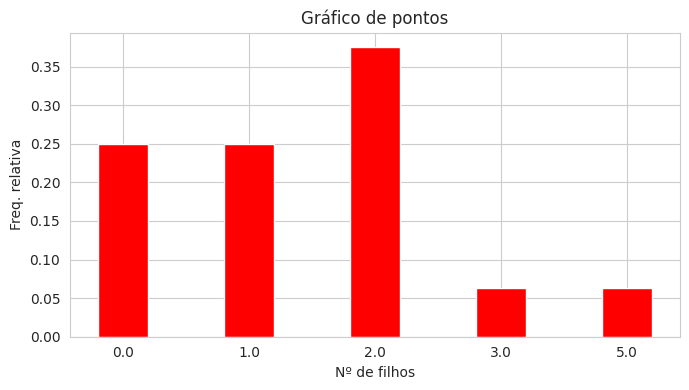

In [16]:
# Equivalente ao geom_dotplot do ggplot
fig, ax = plt.subplots(figsize=(7, 4))
contagem = N_Filhos.value_counts(normalize=True).sort_index()
ax.bar(contagem.index.astype(str), contagem.values, color='red', width=0.4)
ax.set_title('Gráfico de pontos')
ax.set_xlabel('Nº de filhos')
ax.set_ylabel('Freq. relativa')
plt.tight_layout()
plt.show()

## 4. Medidas Resumo

In [17]:
# Equivalente ao summary() do R
display(banco1_modulo1.describe(include='all'))

,N,EstadoCivil,GrauInstrucao,N_Filhos,Salario_Min,Anos,Meses,Regiao_Procedencia,GrauInstrucao1
count,30.000000,30,30,16.000000,30.000000,30.000000,30.000000,30,30.000000
unique,NaN,2,3,NaN,NaN,NaN,NaN,3,NaN
top,NaN,casado,ens_medio,NaN,NaN,NaN,NaN,outra,NaN
freq,NaN,16,16,NaN,NaN,NaN,NaN,12,NaN
mean,15.500000,NaN,NaN,1.500000,9.628667,33.733333,5.533333,NaN,1.666667
std,8.803408,NaN,NaN,1.316561,3.220984,6.549195,3.370596,NaN,0.606478
min,1.000000,NaN,NaN,0.000000,4.000000,20.000000,0.000000,NaN,1.000000
25%,8.250000,NaN,NaN,0.750000,7.402500,29.250000,3.250000,NaN,1.000000
50%,15.500000,NaN,NaN,1.500000,9.240000,34.000000,6.000000,NaN,2.000000
75%,22.750000,NaN,NaN,2.000000,11.897500,38.750000,8.000000,NaN,2.000000


In [18]:
# Equivalente ao describe() do pacote psych do R (estatísticas estendidas)
def describe_psych(df):
    num = df.select_dtypes(include='number')
    desc = num.describe().T
    desc['median']  = num.median()
    desc['skew']    = num.skew()
    desc['kurtosis']= num.kurtosis()
    desc['se']      = num.sem()
    desc['range']   = num.max() - num.min()
    return desc[['count','mean','std','se','median','min','max','range','skew','kurtosis']]

display(describe_psych(banco1_modulo1))

,count,mean,std,se,median,min,max,range,skew,kurtosis
N,30.0,15.500000,8.803408,1.607275,15.50,1.0,30.00,29.00,0.000000,-1.200000
N_Filhos,16.0,1.500000,1.316561,0.329140,1.50,0.0,5.00,5.00,1.101771,2.127739
Salario_Min,30.0,9.628667,3.220984,0.588068,9.24,4.0,15.99,11.99,0.206416,-0.795879
Anos,30.0,33.733333,6.549195,1.195714,34.00,20.0,46.00,26.00,-0.113154,-0.638162
Meses,30.0,5.533333,3.370596,0.615384,6.00,0.0,11.00,11.00,-0.254420,-0.939510
GrauInstrucao1,30.0,1.666667,0.606478,0.110727,2.00,1.0,3.00,2.00,0.294440,-0.550223


## 5. Tabelas para Variáveis Qualitativas

In [19]:
# Frequência e percentual – EstadoCivil
tab_ec = (banco1_modulo1['EstadoCivil']
          .value_counts()
          .reset_index()
          .rename(columns={'count': 'n', 'EstadoCivil': 'EstadoCivil'}))
tab_ec['percentual'] = (tab_ec['n'] / tab_ec['n'].sum() * 100).round(1)
display(tab_ec)

,EstadoCivil,n,percentual
0,casado,16,53.3
1,solteiro,14,46.7


In [20]:
# Tabela cruzada (duas variáveis qualitativas)
tab_cruzada = (banco1_modulo1
               .groupby(['EstadoCivil', 'GrauInstrucao'])
               .size()
               .reset_index(name='n'))

tab_cruzada['percentual'] = (tab_cruzada.groupby('EstadoCivil')['n']
                              .transform(lambda x: (x / x.sum() * 100).round(1)))
display(tab_cruzada)

,EstadoCivil,GrauInstrucao,n,percentual
0,casado,ens_fundamental,5,31.2
1,casado,ens_medio,10,62.5
2,casado,superior,1,6.2
3,solteiro,ens_fundamental,7,50.0
4,solteiro,ens_medio,6,42.9
5,solteiro,superior,1,7.1


## 6. Teste Qui-Quadrado e Teste Exato de Fisher

In [21]:
# Tabela de contingência
tab_chi = pd.crosstab(banco1_modulo1['EstadoCivil'], banco1_modulo1['GrauInstrucao'])
display(tab_chi)

# Teste Qui-Quadrado
chi2, p_chi, dof, esperadas = chi2_contingency(tab_chi)
print(f'\nTeste Qui-Quadrado:')
print(f'  X² = {chi2:.4f}  |  gl = {dof}  |  p-valor = {p_chi:.4f}')
print('\nFrequências esperadas:')
display(pd.DataFrame(esperadas, index=tab_chi.index, columns=tab_chi.columns).round(2))
print('\nOBS: quando existe célula com valor esperado < 5, o qui-quadrado não é adequado.')

GrauInstrucao,ens_fundamental,ens_medio,superior
EstadoCivil,,,
casado,5,10,1
solteiro,7,6,1



Teste Qui-Quadrado:
  X² = 1.2054  |  gl = 2  |  p-valor = 0.5473

Frequências esperadas:


GrauInstrucao,ens_fundamental,ens_medio,superior
EstadoCivil,,,
casado,6.4,8.53,1.07
solteiro,5.6,7.47,0.93



OBS: quando existe célula com valor esperado < 5, o qui-quadrado não é adequado.


In [22]:
# Teste Exato de Fisher (disponível diretamente apenas para tabelas 2×2)
# Para tabelas maiores, usa-se chi2_contingency com simulação ou barnard
if tab_chi.shape == (2, 2):
    odds, p_fisher = fisher_exact(tab_chi)
    print(f'Teste Exato de Fisher: odds ratio = {odds:.4f}  |  p-valor = {p_fisher:.4f}')
else:
    from scipy.stats import chi2_contingency
    chi2_f, p_fisher, dof_f, _ = chi2_contingency(tab_chi, lambda_='log-likelihood')
    print(f'Tabela {tab_chi.shape}: usando G-test (equivalente ao Fisher para tabelas maiores)')
    print(f'  G = {chi2_f:.4f}  |  gl = {dof_f}  |  p-valor = {p_fisher:.4f}')

Tabela (2, 3): usando G-test (equivalente ao Fisher para tabelas maiores)
  G = 1.2121  |  gl = 2  |  p-valor = 0.5455


## 7. Duas Variáveis Quantitativas

### 7.1 Gráfico de Dispersão com Linha de Tendência

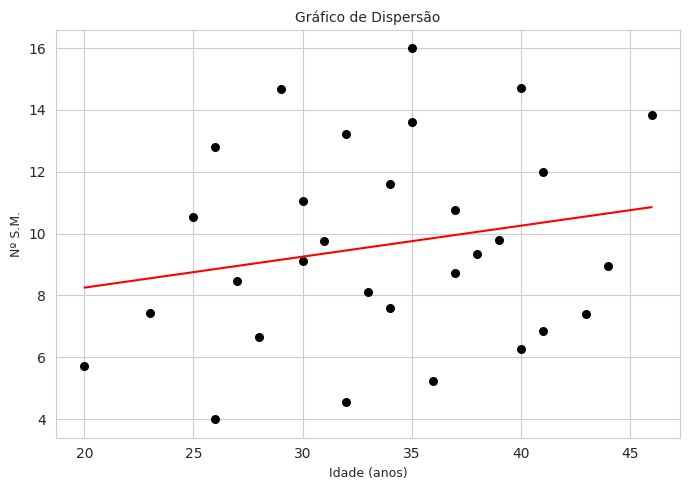

In [23]:
df_clean = banco1_modulo1[['Anos', 'Salario_Min']].dropna()
x = df_clean['Anos']
y = df_clean['Salario_Min']

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, color='black', s=30)

# Linha de tendência linear
m, b = np.polyfit(x, y, 1)
ax.plot(np.sort(x), m * np.sort(x) + b, color='red')

ax.set_title('Gráfico de Dispersão', fontsize=10)
ax.set_xlabel('Idade (anos)', fontsize=9)
ax.set_ylabel('Nº S.M.', fontsize=9)
plt.tight_layout()
plt.show()

### 7.2 Avaliação de Normalidade

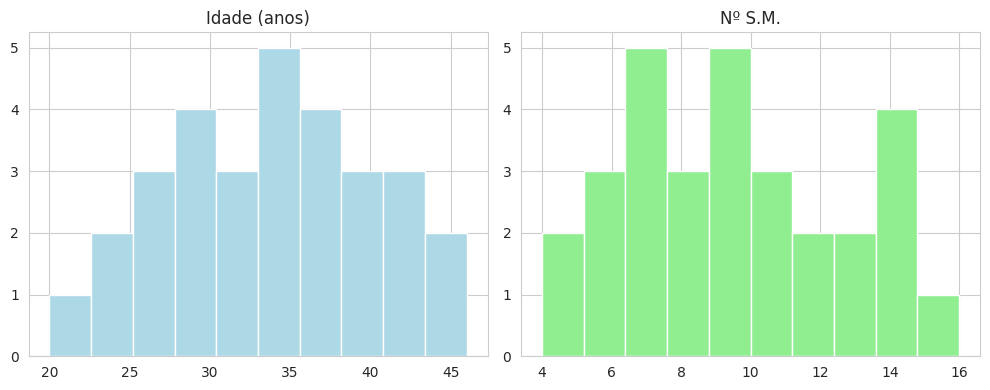

Shapiro-Wilk – Anos:       W = 0.9878  |  p-valor = 0.9746
Shapiro-Wilk – Salario_Min: W = 0.9765  |  p-valor = 0.7255


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(Anos.dropna(), color='lightblue', edgecolor='white')
axes[0].set_title('Idade (anos)')
axes[1].hist(Salario_Min.dropna(), color='lightgreen', edgecolor='white')
axes[1].set_title('Nº S.M.')
plt.tight_layout()
plt.show()

# Teste de Shapiro-Wilk
stat_a, p_a = shapiro(Anos.dropna())
stat_s, p_s = shapiro(Salario_Min.dropna())
print(f'Shapiro-Wilk – Anos:       W = {stat_a:.4f}  |  p-valor = {p_a:.4f}')
print(f'Shapiro-Wilk – Salario_Min: W = {stat_s:.4f}  |  p-valor = {p_s:.4f}')

### 7.3 Correlações

In [25]:
# Correlação de Pearson
r_p, p_p = pearsonr(Salario_Min.dropna(), Anos.dropna())
print(f'Pearson:  r = {r_p:.4f}  |  p-valor = {p_p:.4f}')

# Correlação de Spearman
r_s, p_s = spearmanr(Salario_Min.dropna(), Anos.dropna())
print(f'Spearman: r = {r_s:.4f}  |  p-valor = {p_s:.4f}')

# Ranks (equivalente ao rank() do R)
print('\nRanks de Anos:')
print(stats.rankdata(Anos.dropna()))

Pearson:  r = 0.2035  |  p-valor = 0.2807
Spearman: r = 0.1719  |  p-valor = 0.3637

Ranks de Anos:
[12.5 19.  28.   6.   4.5  7.  26.5 24.5 29.  23.  26.5 30.  15.5 11.
 15.5 17.5 14.   9.5 20.5 12.5  8.  24.5  1.   2.  20.5 22.   9.5 17.5
  3.   4.5]


In [26]:
# Matrizes de correlação – colunas 5 a 7 (índice 4 a 6 em Python)
cols_num = banco1_modulo1.iloc[:, 4:7].dropna()

print('Matriz de Correlação de Pearson:')
display(cols_num.corr(method='pearson').round(4))

print('\nMatriz de Correlação de Spearman:')
display(cols_num.corr(method='spearman').round(4))

Matriz de Correlação de Pearson:


,Salario_Min,Anos,Meses
Salario_Min,1.0000,0.2035,-0.0346
Anos,0.2035,1.0000,-0.2558
Meses,-0.0346,-0.2558,1.0000



Matriz de Correlação de Spearman:


,Salario_Min,Anos,Meses
Salario_Min,1.0000,0.1719,-0.0157
Anos,0.1719,1.0000,-0.2721
Meses,-0.0157,-0.2721,1.0000


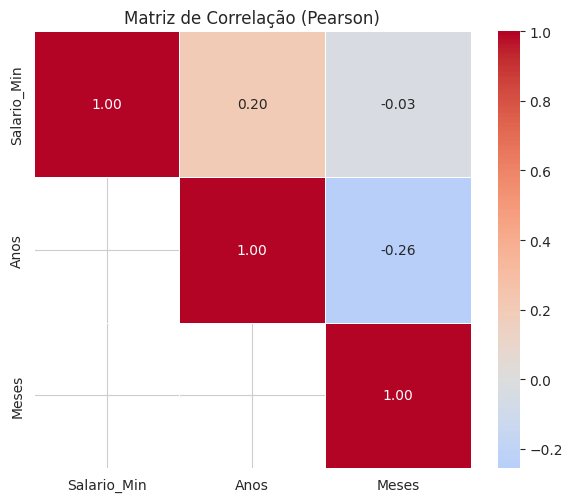

In [27]:
# Visualização da Matriz de Correlação (equivalente ao corrplot)
import matplotlib.patches as mpatches

matrixcorr = cols_num.corr(method='pearson')

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.tril(np.ones_like(matrixcorr, dtype=bool), k=-1)  # apenas triângulo superior
sns.heatmap(matrixcorr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlação (Pearson)')
plt.tight_layout()
plt.show()

## 8. Variável Qualitativa × Quantitativa – Testes de Hipóteses

Shapiro-Wilk – Salario_Min: W = 0.9765  |  p-valor = 0.7255


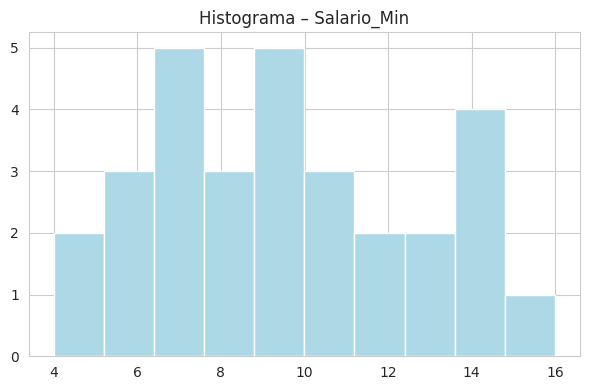

In [28]:
# Teste de Normalidade
stat_sw, p_sw = shapiro(Salario_Min.dropna())
print(f'Shapiro-Wilk – Salario_Min: W = {stat_sw:.4f}  |  p-valor = {p_sw:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(Salario_Min.dropna(), color='lightblue', edgecolor='white')
ax.set_title('Histograma – Salario_Min')
plt.tight_layout()
plt.show()

In [29]:
# Teste de igualdade de variâncias (equivalente ao var.test do R)
grupos_ec = [g['Salario_Min'].dropna().values
             for _, g in banco1_modulo1.groupby('EstadoCivil')]

stat_lev, p_lev = levene(*grupos_ec)
print(f'Teste de Levene (igualdade de variâncias): F = {stat_lev:.4f}  |  p-valor = {p_lev:.4f}')

Teste de Levene (igualdade de variâncias): F = 1.0605  |  p-valor = 0.3119


In [30]:
# Teste T – dois grupos independentes (var.equal=TRUE → equal_var=True)
nomes_ec = banco1_modulo1['EstadoCivil'].unique()
g1 = banco1_modulo1.loc[banco1_modulo1['EstadoCivil'] == nomes_ec[0], 'Salario_Min'].dropna()
g2 = banco1_modulo1.loc[banco1_modulo1['EstadoCivil'] == nomes_ec[1], 'Salario_Min'].dropna()

t_stat, p_t = ttest_ind(g1, g2, equal_var=True)
print(f'Teste T (variâncias iguais): t = {t_stat:.4f}  |  p-valor = {p_t:.4f}')
print(f'Grupos: {nomes_ec[0]} (n={len(g1)})  vs  {nomes_ec[1]} (n={len(g2)})')

Teste T (variâncias iguais): t = 1.3653  |  p-valor = 0.1830
Grupos: casado (n=16)  vs  solteiro (n=14)


In [31]:
# Teste de Mann-Whitney (Wilcoxon rank-sum)
u_stat, p_mw = mannwhitneyu(g1, g2, alternative='two-sided')
print(f'Mann-Whitney: U = {u_stat:.4f}  |  p-valor = {p_mw:.4f}')

Mann-Whitney: U = 143.0000  |  p-valor = 0.2048


In [32]:
# ANOVA de um fator – Salario_Min ~ Regiao_Procedencia
modelo1 = ols('Salario_Min ~ C(Regiao_Procedencia)', data=banco1_modulo1).fit()
anova1 = sm.stats.anova_lm(modelo1, typ=1)
print('ANOVA 1 – Salario_Min ~ Regiao_Procedencia')
display(anova1)

# Verificação dos pressupostos
stat_res1, p_res1 = shapiro(modelo1.resid)
print(f'\nNormalidade dos resíduos (Shapiro-Wilk): W = {stat_res1:.4f}  |  p-valor = {p_res1:.4f}')

grupos_rp = [g['Salario_Min'].dropna().values
             for _, g in banco1_modulo1.groupby('Regiao_Procedencia')]
stat_bart1, p_bart1 = bartlett(*grupos_rp)
print(f'Homogeneidade das variâncias (Bartlett): X² = {stat_bart1:.4f}  |  p-valor = {p_bart1:.4f}')

ANOVA 1 – Salario_Min ~ Regiao_Procedencia


,df,sum_sq,mean_sq,F,PR(>F)
C(Regiao_Procedencia),2.0,7.095365,3.547683,0.32606,0.724564
Residual,27.0,293.771982,10.880444,NaN,NaN



Normalidade dos resíduos (Shapiro-Wilk): W = 0.9796  |  p-valor = 0.8161
Homogeneidade das variâncias (Bartlett): X² = 0.9444  |  p-valor = 0.6236


In [33]:
# ANOVA de um fator – Salario_Min ~ GrauInstrucao
modelo2 = ols('Salario_Min ~ C(GrauInstrucao)', data=banco1_modulo1).fit()
anova2 = sm.stats.anova_lm(modelo2, typ=1)
print('ANOVA 2 – Salario_Min ~ GrauInstrucao')
display(anova2)

stat_res2, p_res2 = shapiro(modelo2.resid)
print(f'\nNormalidade dos resíduos (Shapiro-Wilk): W = {stat_res2:.4f}  |  p-valor = {p_res2:.4f}')

grupos_gi = [g['Salario_Min'].dropna().values
             for _, g in banco1_modulo1.groupby('GrauInstrucao')]
stat_bart2, p_bart2 = bartlett(*grupos_gi)
print(f'Homogeneidade das variâncias (Bartlett): X² = {stat_bart2:.4f}  |  p-valor = {p_bart2:.4f}')

ANOVA 2 – Salario_Min ~ GrauInstrucao


,df,sum_sq,mean_sq,F,PR(>F)
C(GrauInstrucao),2.0,65.800305,32.900152,3.778939,0.035729
Residual,27.0,235.067042,8.706187,NaN,NaN



Normalidade dos resíduos (Shapiro-Wilk): W = 0.9658  |  p-valor = 0.4309
Homogeneidade das variâncias (Bartlett): X² = 0.4501  |  p-valor = 0.7985


In [34]:
# Tukey HSD – pós-teste quando ANOVA é significativa
df_tukey = banco1_modulo1[['Salario_Min', 'GrauInstrucao']].dropna()
tukey = pairwise_tukeyhsd(endog=df_tukey['Salario_Min'],
                          groups=df_tukey['GrauInstrucao'],
                          alpha=0.05)
print('Tukey HSD – Salario_Min por GrauInstrucao')
print(tukey)

Tukey HSD – Salario_Min por GrauInstrucao
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
     group1       group2  meandiff p-adj   lower  upper  reject
---------------------------------------------------------------
ens_fundamental ens_medio   2.8821 0.0422  0.0883 5.6759   True
ens_fundamental  superior   3.8233 0.2248 -1.7642 9.4109  False
      ens_medio  superior   0.9412 0.9054 -4.5456 6.4281  False
---------------------------------------------------------------


In [35]:
# Medidas resumo por grupo
medidas_grupo = (banco1_modulo1
                 .groupby('GrauInstrucao')['Salario_Min']
                 .agg(n='count', media='mean', mediana='median', desv_pad='std')
                 .reset_index())
display(medidas_grupo.round(4))

,GrauInstrucao,n,media,mediana,desv_pad
0,ens_fundamental,12,7.8367,7.125,2.9565
1,ens_medio,16,10.7188,10.265,3.0151
2,superior,2,11.6600,11.660,1.5981


## 9. Testes Não Paramétricos

In [36]:
# Teste de Kruskal-Wallis
kruskal_stat, kruskal_p = kruskal(*grupos_gi)
print(f'Kruskal-Wallis: H = {kruskal_stat:.4f}  |  p-valor = {kruskal_p:.4f}')

Kruskal-Wallis: H = 6.6581  |  p-valor = 0.0358


In [37]:
# Teste de Dunn (pós-Kruskal) com correção de Bonferroni
df_dunn = banco1_modulo1[['Salario_Min', 'GrauInstrucao']].dropna()

print('Dunn – correção Bonferroni:')
dunn_bonf = sp.posthoc_dunn(df_dunn, val_col='Salario_Min',
                             group_col='GrauInstrucao', p_adjust='bonferroni')
display(dunn_bonf.round(4))

print('\nDunn – correção Holm:')
dunn_holm = sp.posthoc_dunn(df_dunn, val_col='Salario_Min',
                             group_col='GrauInstrucao', p_adjust='holm')
display(dunn_holm.round(4))

print('\nDunn – correção Hochberg (fdr_bh como aproximação):')
dunn_hochb = sp.posthoc_dunn(df_dunn, val_col='Salario_Min',
                              group_col='GrauInstrucao', p_adjust='fdr_bh')
display(dunn_hochb.round(4))

Dunn – correção Bonferroni:


,ens_fundamental,ens_medio,superior
ens_fundamental,1.0000,0.052,0.3055
ens_medio,0.0520,1.000,1.0000
superior,0.3055,1.000,1.0000



Dunn – correção Holm:


,ens_fundamental,ens_medio,superior
ens_fundamental,1.0000,0.0520,0.2037
ens_medio,0.0520,1.0000,0.6496
superior,0.2037,0.6496,1.0000



Dunn – correção Hochberg (fdr_bh como aproximação):


,ens_fundamental,ens_medio,superior
ens_fundamental,1.0000,0.0520,0.1528
ens_medio,0.0520,1.0000,0.6496
superior,0.1528,0.6496,1.0000


In [38]:
# Recodificação de variável (equivalente ao recode() do R/dplyr)
mapa_grau = {'ens_fundamental': 1, 'ens_medio': 2, 'superior': 3}
banco1_modulo1['grauinst'] = banco1_modulo1['GrauInstrucao'].map(mapa_grau)
print(banco1_modulo1[['GrauInstrucao', 'grauinst']].drop_duplicates().sort_values('grauinst'))

      GrauInstrucao  grauinst
0   ens_fundamental         1
12        ens_medio         2
28         superior         3


In [39]:
# Teste de Conover-Iman (pós-Kruskal robusto)
df_conover = banco1_modulo1[['Salario_Min', 'GrauInstrucao']].dropna()
print('Conover-Iman – comparações múltiplas:')
conover = sp.posthoc_conover(df_conover, val_col='Salario_Min',
                             group_col='GrauInstrucao', p_adjust='holm')
display(conover.round(4))

Conover-Iman – comparações múltiplas:


,ens_fundamental,ens_medio,superior
ens_fundamental,1.0000,0.0432,0.1666
ens_medio,0.0432,1.0000,0.6215
superior,0.1666,0.6215,1.0000
